# Report: mac1 diffuse and goodvibes analysis

In [1]:
disp(datestr(now))

15-Sep-2026 08:21:52


## Reference halos

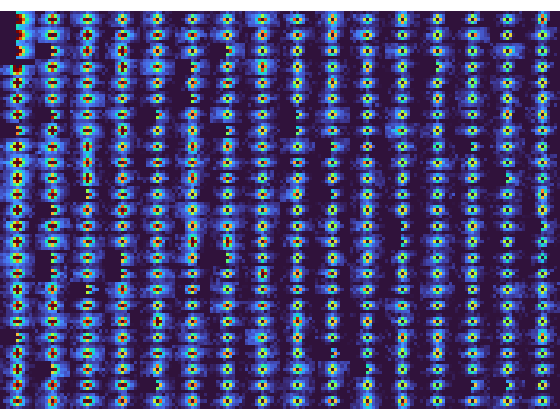

In [12]:
load proc/reference_halos.mat I sigma
fh = figure(1);clf;fh.Position(3:4) = [300,213];

ndata = nnz(~isinf(sigma));
I(isinf(sigma)) = NaN;

m = cell(size(I,1),1);
for j=1:size(I,1)
    m{j} = squeeze(I(j,ceil(size(I,2)/2),:,:));
end
I_std = std(I(~isnan(I)));
I_med = median(I(~isnan(I)));
imagesc(cell2mat(reshape(m,25,[])),[I_med - .2*I_std,I_med + 8*I_std]);
set(gca,'Position',[0,0,1,1]);
axis image;axis off;colormap turbo

## GOODVIBES refinement

In [11]:
load proc/goodvibes_fit.mat refineLog
load proc/reference_halos.mat sigma
ndata = nnz(~isinf(sigma));

table_cols = {'Stage','Spring type','Parameterization','Number of parameters','Number of iterations','Chi-squared'};

T = [];
for j=1:numel(refineLog)
    st = refineLog(j).springType;
    pa = refineLog(j).parameterization;
    np = numel(refineLog(j).pfit);
    ni = refineLog(j).history(end).iteration;
    x2 = refineLog(j).history(end).resnorm/ndata;
    t = table(j,{st},{pa},np,ni,x2,'VariableNames',table_cols);
    T = [T;t];
end
T


T =

  4x6 table

    Stage    Spring type     Parameterization     Number of parameters    Number of iterations    Chi-squared
    _____    ____________    _________________    ____________________    ____________________    ___________

      1      {'Gaussian'}    {'global'       }              1                       4               2.2126   
      2      {'Gaussian'}    {'interface'    }              4                      10                2.119   
      3      {'hybrid'  }    {'interface'    }              8                      24               1.8681   
      4      {'hybrid'  }    {'uniquegrouped'}            134                      47               1.6932   



## Intensity statistics

In [13]:
%%file calc_intensity_stats.m

function T = calc_intensity_stats(MT,I,I1,I2,I_latt,edges)

SVR = proc.script.StatisticsVsRadius(...
    'edges',edges,...
    'Basis',MT.Basis,...
    'PeriodicGrid',MT.Grid);

stats_exp_half = SVR.run(I1,I2);
stats_ld_exp = SVR.run(I_latt,I);

cc12 = stats_exp_half.cc;
cc12(cc12<0) = 0; % make sure ccstar is real
ccstar = sqrt(2*cc12./(1+cc12));

s = stats_ld_exp.r;
sigmaI_exp = sqrt(stats_ld_exp.var2).*ccstar;
sigmaI_latt = sqrt(stats_ld_exp.var1);
cclatt = stats_ld_exp.cc;

T = table(s,sigmaI_exp,sigmaI_latt,cclatt,ccstar);

end

Created file '/nfs/chess/user/spm82/mdx/mac1_20251105_goodvibes/calc_intensity_stats.m'.


In [16]:
%%file plot_intensity_stats.m

function [t,ah] = plot_intensity_stats(T)

t = tiledlayout(2,1);
%t.XLabel.String = '1/d (Å^{-1})';
t.TileSpacing='tight';
t.Padding='compact';

bin_width = T.s(end)-T.s(end-1);
slim = T.s(end) + bin_width/2;
ymax = 1.2*max(T.sigmaI_exp);

nexttile;
plot(T.s,T.sigmaI_exp,'k.-')
hold on;
plot(T.s,T.sigmaI_latt,'m.-')
ah(1) = gca;
set(ah(1),'Ylim',[0,ymax],'Xlim',[0,slim],'XTickLabel',{},'Box','Off','TickDir','out')
legend({'expt.','sim.'},'Location','northeast','Box','Off')
ylabel('Standard deviation')

nexttile;
plot(T.s,T.ccstar,'k-','Color',[1,1,1]*.5)
hold on;
plot(T.s,T.cclatt,'k.-');
plot([0,slim],[1,1],'k--');
ah(2) = gca;
set(ah(2),'Ylim',[0,1.05],'Xlim',[0,slim],'Box','Off','TickDir','out')
legend({'CC*','expt. vs. sim.'},'Location','south','Box','Off')
ylabel('Correlation coefficient')
xlabel('1/d (Å^{-1})')

end

Created file '/nfs/chess/user/spm82/mdx/mac1_20251105_goodvibes/plot_intensity_stats.m'.


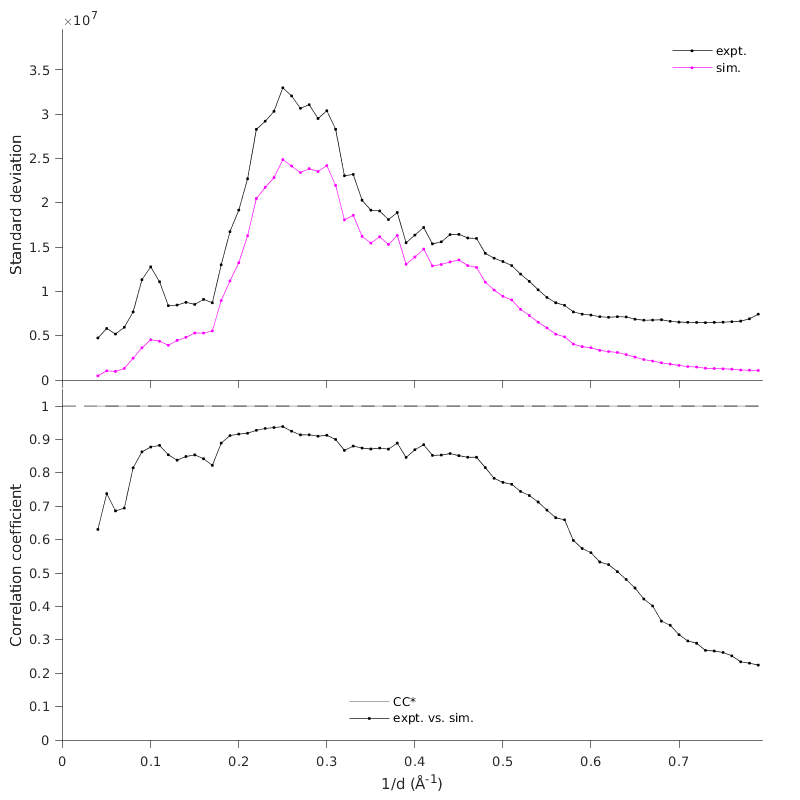

In [72]:
%plot --size 800,800

slim = 0.8;
edges = 0.035:.01:slim;
mapFileName = 'export/mac1_5x5x11_map.h5';
[MT,I] = proc.script.MapTools.import(mapFileName,'total','I');
Ilatt = MT.read_data('export/mac1_5x5x11_goodvibes.h5','supercell','I');

% need to mask integer hkl points, I think
[h,k,l] = MT.Grid.grid();
is_integer = (abs(h-round(h))<1e-6) & (abs(k-round(k))<1e-6) & (abs(l-round(l))<1e-6);
I(is_integer) = nan;
Ilatt(is_integer) = nan;

T = calc_intensity_stats(MT,I,I,I,Ilatt,edges); % hack (there are no I1, I2 half-maps available)
fh = figure(1);clf;
[t,ah] = plot_intensity_stats(T);

## Goodvibes joint ADPs

In [21]:
%%file preprocess_covariance_table.m

function T = preprocess_covariance_table(T)
T.d = sqrt(T.x.^2 + T.y.^2 + T.z.^2);
isIncl = T.d>0;
T = T(isIncl,:);
T.viso = T.v11 + T.v22 + T.v33;
T.vaniso = cat(2,T.v11 - T.viso/3,T.v22 - T.viso/3, T.v33 - T.viso/3, T.v12,T.v13,T.v23);
T = T(:,{'n1','n2','n3','d','viso','vaniso'});
end

Created file '/nfs/chess/user/spm82/mdx/mac1_20251105_goodvibes/preprocess_covariance_table.m'.


In [22]:
%%file compare_covariance_tables.m

function [T,fit_iso,fit_aniso] = compare_covariance_tables(Tdb,Tgv)

discoball = preprocess_covariance_table(Tdb);
goodvibes = preprocess_covariance_table(Tgv);
T = innerjoin(discoball,goodvibes,'Keys',{'n1','n2','n3'},'RightVariables',{'viso','vaniso'});

x = T.viso_discoball;
y = T.viso_goodvibes;

p = polyfit(x,y,1);
ccmat = corrcoef(x,y);
cc = ccmat(1,2);
fit_iso = struct('x',x,'y',y,'cc',cc,'p',p);

x = T.vaniso_discoball(:);
y = T.vaniso_goodvibes(:);

p = polyfit(x,y,1);
ccmat = corrcoef(x,y);
cc = ccmat(1,2);
fit_aniso = struct('x',x,'y',y,'cc',cc,'p',p);

end

Created file '/nfs/chess/user/spm82/mdx/mac1_20251105_goodvibes/compare_covariance_tables.m'.


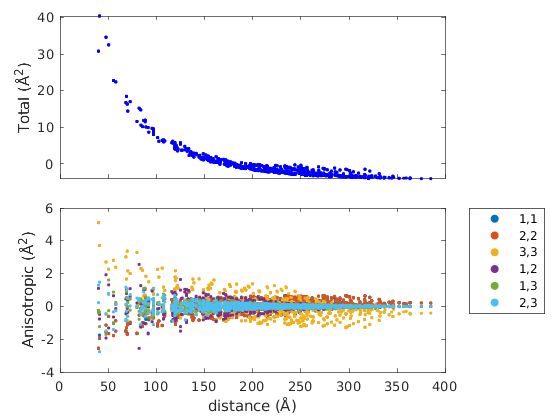

In [24]:
Tdb = readtable('export/mac1_5x5x11_goodvibes_com_covariances.csv');
T = preprocess_covariance_table(Tdb);

fh = figure(1);clf;fh.Position(3:4) = [350,250];
t = tiledlayout(2,1,'TileSpacing','compact','Padding','compact');
nexttile;scatter(T.d,T.viso,5,'Filled','MarkerFaceColor','b');
ylabel('Total (Å^2)');box on;set(gca,'XTickLabel',{});

nexttile;scatter(T.d,T.vaniso,5,'Filled');
lg = legend({'1,1','2,2','3,3','1,2','1,3','2,3'});
lg.Location = 'bestoutside';
xlabel('distance (Å)');ylabel('Anisotropic (Å^2)');box on;


## DISCOBALL analysis

TODO

## DISCOBALL validation

TODO

## GOODVIBES ADPs

In [25]:
%%file tls_analysis.m

function [T,L,S,rcor,Tcor,Lcor,Scor] = tls_analysis(C)

C = C(1:6,1:6);

T = C(1:3,1:3); % A^2
L = C(4:6,4:6);
S = C(4:6,1:3);

A = trace(L)*eye(3)-L;
b = [S(2,3)-S(3,2);S(3,1)-S(1,3);S(1,2)-S(2,1)];
rcor = A\b;

cmat = @(r1,r2,r3) sparse([3,1,2,2,3,1],[2,3,1,3,1,2],[r1,r2,r3,-r1,-r2,-r3],3,3);

Oshift = kron(sparse(1,2,1,2,2),cmat(-rcor(1),-rcor(2),-rcor(3))) + speye(6,6);

C0 = Oshift*C*Oshift';

Tcor = C0(1:3,1:3); % A^2
Lcor = C0(4:6,4:6);
Scor = C0(4:6,1:3);

end

Created file '/nfs/chess/user/spm82/mdx/mac1_20251105_goodvibes/tls_analysis.m'.


In [35]:
load('proc/atomic_model.mat','AtomFF','Atoms');
Atoms.mdxFormFactor = AtomFF.mdxFormFactor;
load('proc/goodvibes_fit.mat','LD');
load('proc/goodvibes_model.mat','ENM');
tlsori = ENM.Cell.AsymmetricUnit.ori;

C = LD.cov_unitcell;
[T,L,S,rcor,Tcor,Lcor,Scor] = tls_analysis(C);

disp('Center of Mass:')
disp(tlsori)
disp('Center of reaction:')
disp(tlsori + rcor')
disp('T @ center of reaction:')
disp(Tcor)
disp('L @ center of reaction:')
disp(Lcor*(180/pi)^2)
disp('S @ center of reaction:')
disp(Scor*(180/pi))

Center of Mass:
  -30.8106  -11.8709    0.7307

Center of reaction:
  -29.8802  -10.6577   -0.7373

T @ center of reaction:
   33.4276    2.5707    0.2783
    2.5707   34.5723   -0.3057
    0.2783   -0.3057   41.2432

L @ center of reaction:
  225.5303   41.8121  -40.8315
   41.8121  223.3051  -27.1836
  -40.8315  -27.1836  129.4924

S @ center of reaction:
   -2.4167   -6.7650    8.5196
   -6.7650   -8.4164    2.0740
    8.5196    2.0740    1.0156



In [36]:
%%file calc_backbone_bfactors.m
function [stats] = calc_backbone_bfactors(Atoms,C,tlsori,Tcor)

% per-residue B-factors (BACKBONE atoms)
isIncl = Atoms.mdxChemicalGroup=="backbone" & Atoms.mdxAtomicSymbol~="H";
Atoms = Atoms(isIncl,:);

[Atoms.Biso] = calc_Biso(Atoms.mdxFormFactor);
[Atoms.Blatt] = calc_Blatt(Atoms,C,tlsori); 

stats = groupsummary(Atoms,{'chainID','resSeq'},{'min','max','mean'},...
    {'Biso','Blatt'},'IncludeEmptyGroups',true);

stats.Blatt_cor = ones(size(stats,1),1)*8*pi^2*trace(Tcor)/3;

function B = calc_Biso(FF)
U = arrayfun(@(ff) ff.U,FF,'Uni',0);
B = cellfun(@(u) 8*pi^2*trace(u)/3,U);
end

function Blatt = calc_Blatt(Atoms,Clatt,ori)
if nargin < 3 || isempty(ori)
    ori = [0,0,0];
end
P = arrayfun(@(x,y,z) nm.Group(x,y,z).tl2uxyz,Atoms.x - ori(1),Atoms.y - ori(2),Atoms.z - ori(3),'Uni',0);
Ulatt = cellfun(@(p) p*Clatt(1:6,1:6)*p',P,'Uni',0);
Blatt = cellfun(@(u) 8*pi^2*trace(u)/3,Ulatt);
end

end

Created file '/nfs/chess/user/spm82/mdx/mac1_20251105_goodvibes/calc_backbone_bfactors.m'.


In [38]:
%%file Bplot_stacked.m

function [ah,a] = Bplot_stacked(stats)

% colors: https://colorbrewer2.org/#type=qualitative&scheme=Paired&n=3
c1 = [166,206,227]/255;
c2 = [31,120,180]/255;
c3 = [178,223,138]/255;

% data to plot
x = stats.resSeq;
ylatt = stats.mean_Blatt;
ylattcor = stats.Blatt_cor;
yobs = stats.mean_Biso;

% make the plot
a(1) = area(x,yobs); hold on;
a(2) = area(x,ylatt);
a(3) = area(x,ylattcor);

p = plot(x,yobs,'k.-');

% set the colors
a(1).FaceColor = c3;
a(1).EdgeColor = [0,0,0];
a(1).LineWidth = 0.5;
a(2).FaceColor = c2;
a(2).EdgeColor = [0,0,0];
a(3).FaceColor = c1;
a(3).EdgeColor = [0,0,0];

ah = gca;

% set the axis limit
set(ah,'Ylim',[0,Inf],'Xlim',[0,Inf]);
a = [p,a];

end

Created file '/nfs/chess/user/spm82/mdx/mac1_20251105_goodvibes/Bplot_stacked.m'.


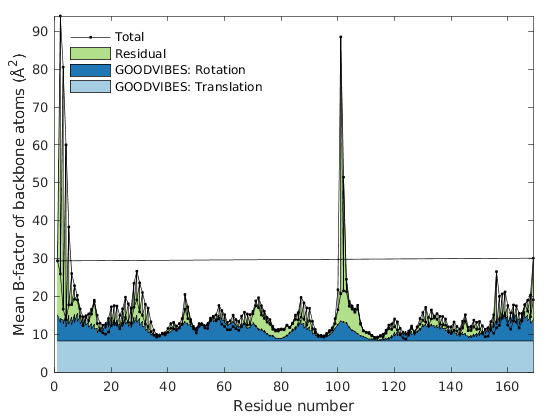

In [47]:
stats = calc_backbone_bfactors(Atoms,C/350,tlsori,Tcor/350);

fh = figure(1);clf;fh.Position(3:4) = [420,220];
t = tiledlayout(1,1,'TileSpacing','compact','Padding','compact');
nexttile;
[ah,a] = Bplot_stacked(stats);
%set(ah,'Ylim',[0,60]); % crop plot (ignore large B-factors)
xlabel('Residue number');
ylabel('Mean B-factor of backbone atoms (Å^2)');
lg = legend(a,{'Total','Residual','GOODVIBES: Rotation','GOODVIBES: Translation'},'Location','northwest','Box','off');

## 3D-ΔPDF subtraction

TODO

## 3D-ΔPDF statistics

TODO

## Diffuse subtraction

In [49]:
%%file orthoslice_grid.m

function [MTx,MTy,MTz] = orthoslice_grid(MT)

% prepare slices
[f1,f2,f3] = MT.Grid.ind2frac(MT.Grid.N(1),MT.Grid.N(2),MT.Grid.N(3));
[MTx] = MT.resize('roi',[0,0,-f2,f2,-f3,f3]);
[MTy] = MT.resize('roi',[-f1,f1,0,0,-f3,f3]);
[MTz] = MT.resize('roi',[-f1,f1,-f2,f2,0,0]);

end

Created file '/nfs/chess/user/spm82/mdx/mac1_20251105_goodvibes/orthoslice_grid.m'.


In [78]:

mapFileName = 'export/mac1_5x5x11_map_sub.h5';

MT = proc.script.MapTools.import(mapFileName,'sub_fill');
[MTx,MTy,MTz] = orthoslice_grid(MT);

% need to mask integer hkl points, I think
[h,k,l] = MTz.Grid.grid();
is_integer = (abs(h-round(h))<1e-6) & (abs(k-round(k))<1e-6) & (abs(l-round(l))<1e-6);

[I_sub_fill,sigma_fill] = MTz.read_data(mapFileName,'sub_fill','I','sigma');
I_sub_fill = MTz.table2array(MTz.array2table(I_sub_fill),'symexpand','replace',NaN);

mapFileName = 'export/mac1_5x5x11_map.h5';
[I_exp] = MTz.read_data(mapFileName,'total','I');
I_exp = MTz.table2array(MTz.array2table(I_exp),'symexpand','replace',NaN);
I_exp(is_integer) = nan;

mapFileName = 'export/mac1_5x5x11_goodvibes.h5';
[I_sim] = MTz.read_data(mapFileName,'supercell','I');
I_sim = MTz.table2array(MTz.array2table(I_sim),'symexpand','replace',NaN);

z = numel(MT.SpaceGroup.generalPositions);
I_sub_fill = I_sub_fill/z;
I_exp = I_exp/z;
I_sim = I_sim/z;

> In proc.script.MapTools>resize_for_target_grid (line 698)
In proc.script/MapTools/read_data (line 574)
mode = symexpand, mode2 = replace, default value = NaN
> In proc.script.MapTools>resize_for_target_grid (line 698)
In proc.script/MapTools/read_data (line 574)
mode = symexpand, mode2 = replace, default value = NaN
> In proc.script.MapTools>resize_for_target_grid (line 698)
In proc.script/MapTools/read_data (line 574)
mode = symexpand, mode2 = replace, default value = NaN


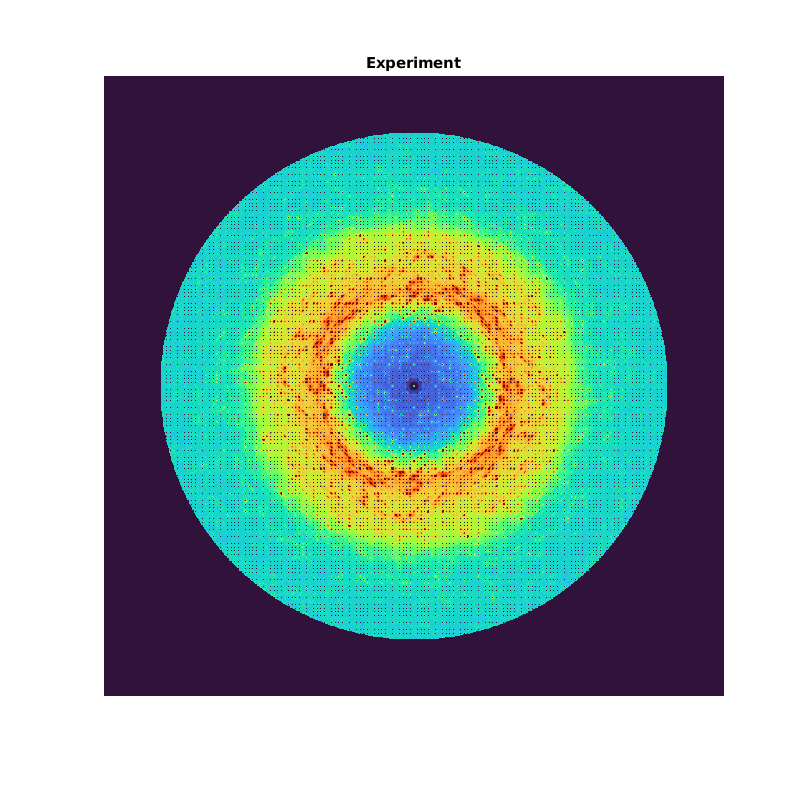

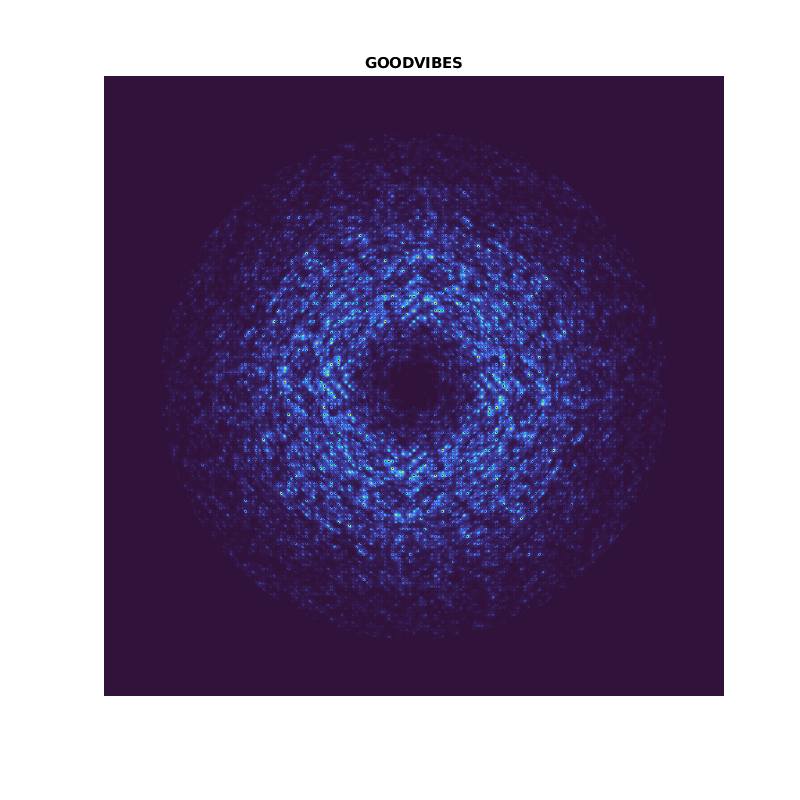

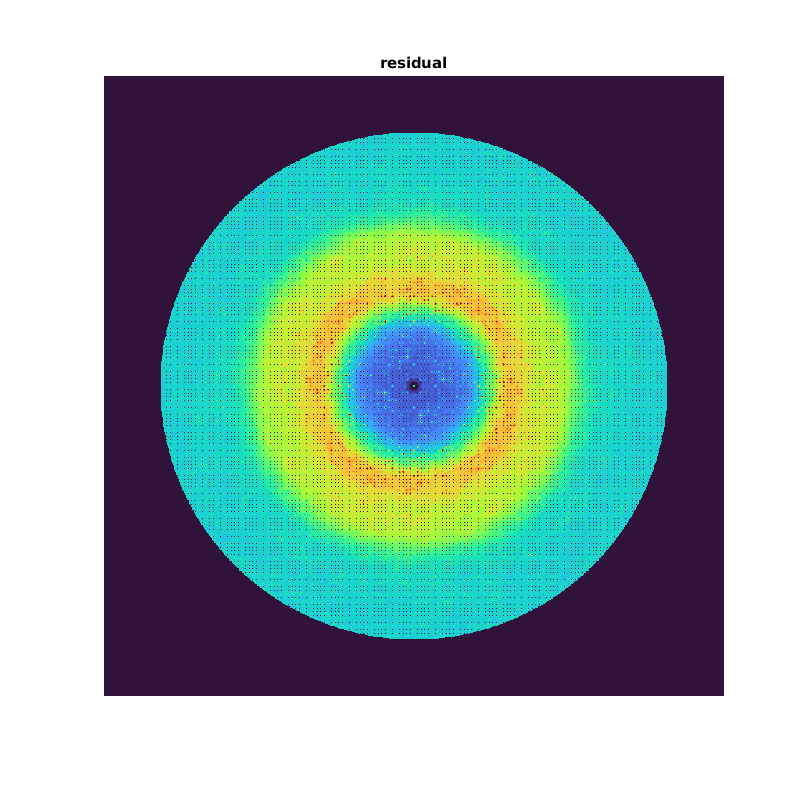

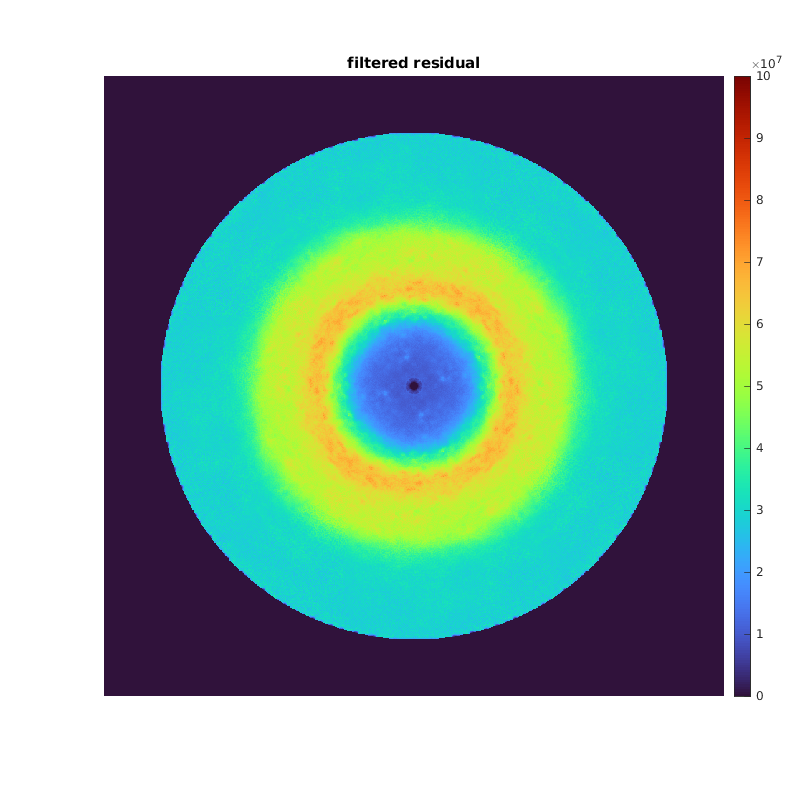

In [79]:
%plot --size 800,800

clim = [0,1E8];
fh = figure(1);clf;%fh.Position(3:4) = [800,800];
imagesc(squeeze(I_exp)',clim);colormap turbo;axis image;axis off;title('Experiment')
fh = figure(2);clf;
imagesc(squeeze(I_sim)',clim);colormap turbo;axis image;axis off;title('GOODVIBES')
fh = figure(3);clf;
imagesc(squeeze(I_exp - I_sim)',clim);colormap turbo;axis image;axis off;title('residual');
fh = figure(4);clf;
nexttile;imagesc(squeeze(I_sub_fill)',clim);colormap turbo;axis image;axis off;title('filtered residual');colorbar